Simuler en Simpy un carrefour avec un feu entre 2 routes, une principale et une secondaire.

Le trafic dans la route principale a un débit de $1$ voiture par seconde.
Le trafic dans la route secondaire a un débit de $0.1$ voitures par seconde.
Le feu est vert pour la route primaire pendant $50$ secondes par minute.
Les voitures emploient $0.5$ secondes pour traverser le carrefour.


Simulation en cours...

--- Scénario 1 (50s/10s) ---
Route principale : 2.13 sec (995 voitures)
Route secondaire : 22.89 sec (96 voitures)

--- Scénario 2 (30s/30s) ---
Route principale : 15.08 sec (1011 voitures)
Route secondaire : 8.95 sec (99 voitures)


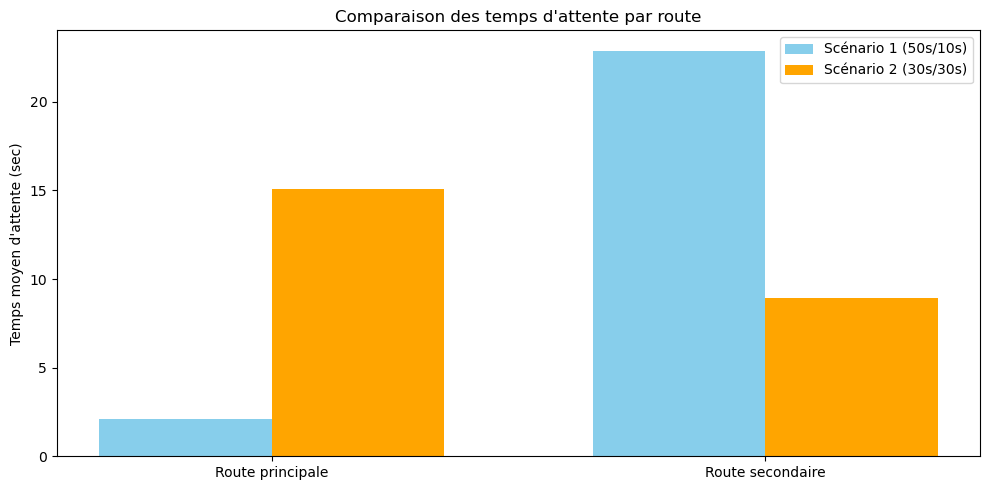

In [ ]:
import simpy
import random
import statistics
import matplotlib.pyplot as plt

# Parameters
SIM_TIME = 1000
CROSSING_TIME = 0.5
ARRIVAL_RATE_MAIN = 1
ARRIVAL_RATE_SECONDARY = 0.1

def traffic_light_controller(env, light_resource, green_main, green_secondary):
    while True:
        # Green for main road
        light_resource.green_for = 'main'
        yield env.timeout(green_main)
        # Green for secondary road
        light_resource.green_for = 'secondary'
        yield env.timeout(green_secondary)


def car(env, name, carname, road_type, light_resource, wait_times):
    arrival = env.now
    #print("Car", carname, road_type, "arrived at ", arrival,  "and found", light_resource.green_for ,"\n")
  
    # Wait until the light is green for this road
    while light_resource.green_for != road_type:
        yield env.timeout(0.01)

    # Once green, request the intersection
    with light_resource.request() as req:
        yield req
        yield env.timeout(CROSSING_TIME)
        wait_times.append(env.now - arrival)
        #print("Car", carname, road_type, " at ", env.now, "passed \n")

    #  the resource is released after the code inside the with block finishes executing.
def car_generator(env, rate, road_type, light_resource, wait_times):
    icar=0
    while True:
        icar=icar+1
        yield env.timeout(random.expovariate(rate))
        env.process(car(env, f"{road_type} car", icar, road_type, light_resource, wait_times))

def run_simulation(green_main, green_secondary):
    env = simpy.Environment()
    wait_main = []
    wait_secondary = []

    # Create a shared resource for the traffic light
    light_resource = simpy.Resource(env, capacity=1)
    light_resource.green_for = 'main'  # Initial state

    env.process(traffic_light_controller(env, light_resource, green_main, green_secondary))
    env.process(car_generator(env, ARRIVAL_RATE_MAIN, 'main', light_resource, wait_main))
    env.process(car_generator(env, ARRIVAL_RATE_SECONDARY, 'secondary', light_resource, wait_secondary))
    env.run(until=SIM_TIME) ## run the simulation
    return wait_main, wait_secondary

def safe_mean(data):
    return statistics.mean(data) if data else 0.0

def print_stats(label, wait_main, wait_sec):
    print(f"\n--- {label} ---")
    print(f"Route principale : {safe_mean(wait_main):.2f} sec ({len(wait_main)} voitures)")
    print(f"Route secondaire : {safe_mean(wait_sec):.2f} sec ({len(wait_sec)} voitures)")

def visualize_results(wait_main_1, wait_sec_1, wait_main_2, wait_sec_2):
    labels = ['Route principale', 'Route secondaire']
    scenario1 = [safe_mean(wait_main_1), safe_mean(wait_sec_1)]
    scenario2 = [safe_mean(wait_main_2), safe_mean(wait_sec_2)]

    x = range(len(labels))
    width = 0.35

    plt.figure(figsize=(10, 5))
    plt.bar(x, scenario1, width, label='Scénario 1 (50s/10s)', color='skyblue')
    plt.bar([i + width for i in x], scenario2, width, label='Scénario 2 (30s/30s)', color='orange')
    plt.xticks([i + width / 2 for i in x], labels)
    plt.ylabel('Temps moyen d\'attente (sec)')
    plt.title('Comparaison des temps d\'attente par route')
    plt.legend()
    plt.tight_layout()
    plt.show()

# Run the simulation
def main():
    print("Simulation en cours...")
    wait_main_1, wait_sec_1 = run_simulation(50, 10)
    wait_main_2, wait_sec_2 = run_simulation(30, 30)

    print_stats("Scénario 1 (50s/10s)", wait_main_1, wait_sec_1)
    print_stats("Scénario 2 (30s/30s)", wait_main_2, wait_sec_2)

    visualize_results(wait_main_1, wait_sec_1, wait_main_2, wait_sec_2)

if __name__ == "__main__":
    main()

In [55]:
random.expovariate(20)

0.05780371793014052